In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import crystal as cr
import grid as grid
from Graphene_TightBinding import TB_graphene_Oscar, qe
from Field import electricField, lambda2T, env_sin2
from pprint import pprint

# graphene parameters
species=cr.species['graphene']

# Create an hexagonal grid

filter=grid.polygonfilter
filter_args={'nsides':6, 'radius': 2/3}
ggr=grid.UniformCartesianGrid(2,[[-0.75,0.75],[-0.75,0.75]],[100,100], filter=filter, filter_args= filter_args)

# Create the graphene crystal
gcr=cr.crystal.from_W90_TB_file(filename='/home/lplaja/crystal_project/dip_prueba/Wannier90 data/gr1NN_tb.dat', grid=ggr, species_name='graphene1NN')

# Create the Field
T0=lambda2T(800e-9)
tt=grid.UniformCartesianGrid(1,limits=[0,8*T0], nptx=1024*8)

Efield=electricField(tt,I_W__cm2=5e10,lambda0_nm=800, env=env_sin2)

# Create the TightBinding object

gtb=TB_graphene_Oscar(gcr, Efield)

Kpv=cr.vector_in_cart(gcr.parameters['reciprocal symmetry points']['Kpv'], basis=gcr.parameters['reciprocal vectors'])
Kp=cr.vector_in_cart(species['reciprocal symmetry points']['Kp'], basis=species['reciprocal vectors'])
M=cr.vector_in_cart(species['reciprocal symmetry points']['M'], basis=species['reciprocal vectors'])
G=cr.vector_in_cart(species['reciprocal symmetry points']['Gamma'], basis=species['reciprocal vectors'])

fig,ax=plt.subplots(1,4,figsize=(16,3.5))

for iax in ax:
    iax.set_xlim(-1,1)
    iax.set_ylim(-1,1)

x=gtb.k
ax[0].scatter(x[:,0],x[:,1], c=gtb.Ek(gtb.k)[:,1])
ax[1].scatter(x[:,0],x[:,1], c=gtb.phik(gtb.k))
ax[2].scatter(x[:,0],x[:,1], c=gtb.Dk(gtb.k)[:,0]/abs(qe)*gcr.reciprocal_lattice_unit, vmin=-2.0, vmax=2.0)
ax[3].scatter(x[:,0],x[:,1], c=gtb.Dk(gtb.k)[:,1], vmin=-2.0, vmax=2.0)

print(np.max(gtb.Dk(gtb.k)[:,1]/abs(qe)*gcr.reciprocal_lattice_unit))

ImportError: cannot import name 'TB_graphene_Oscar' from 'Graphene_TightBinding' (/Users/lplaja/Desarrollo/grafeno/crystal_project/src/Graphene_TightBinding.py)

In [8]:
import numpy as np
import crystal as cr
import grid as grid
from Graphene_TightBinding import TB_graphene_CMCP, qe, epsk, hbar
from Field import polarizedElectricField, lambda2T, env_sin2

# Create an hexagonal grid

filter=grid.polygonfilter
filter_args={'nsides':6, 'radius': 2/3}
ggr=grid.UniformCartesianGrid(2,[[-0.75,0.75],[-0.75,0.75]],[200,200], filter=filter, filter_args= filter_args)

# Create the graphene crystal
gcr=cr.crystal(cr.species['graphene'], grid=ggr, space='reciprocal')

# Create the Field
T0=lambda2T(800e-9)
#npt=1024*32
npt=1024*16
tt=grid.UniformCartesianGrid(1,limits=[0,8*T0], nptx=npt)

Efield=polarizedElectricField(tt,I_W__cm2=5.5e13,lambda0_nm=800, env=env_sin2, phi_rad=-0*np.pi/2, chi_rad=0*np.pi/2,ellip=0)

print(Efield.E0/1e10)

# Create the TightBinding object

gtb=TB_graphene_CMCP(gcr, Efield)

# Evolution

CM, CP=gtb.rk_evolve(gtb.CM, gtb.CP, gtb.k[:,0],gtb.k[:,1] , from_it=0, to_it=int(tt.npts/8*2))
CM, CP=gtb.rk_evolve(gtb.CM, gtb.CP, gtb.k[:,0],gtb.k[:,1] , from_it=int(tt.npts/8*2), to_it=int(tt.npts/8*4))



2.0356899192969893


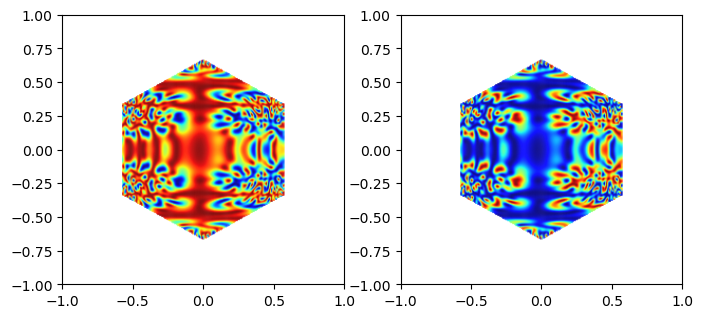

In [9]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(1,2,figsize=(8,3.5))

for iax in ax:
    iax.set_xlim(-1,1)
    iax.set_ylim(-1,1)

x=gtb.k
ax[0].scatter(x[:,0],x[:,1], c=np.abs(gtb.Cv()[:])**2, s=.1, vmin=0, vmax=1, cmap='jet')
ax[1].scatter(x[:,0],x[:,1], c=np.abs(gtb.Cc()[:])**2, s=.1, vmin=0, vmax=1,cmap='jet')


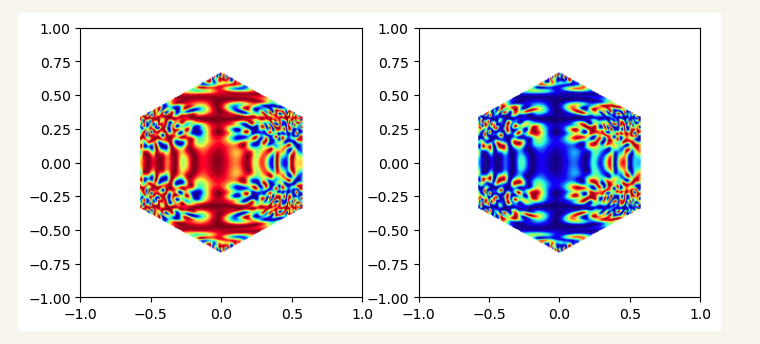

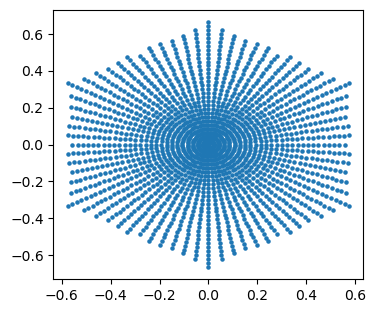

In [13]:
import numpy as np
import crystal as cr
import grid as grid
from Graphene_TightBinding import TB_graphene_CMCP, qe, epsk, hbar
from Field import polarizedElectricField, lambda2T, env_sin2
import matplotlib.pyplot as plt

# Create an hexagonal grid

filter=grid.polygonfilter
filter_args={'nsides':6, 'radius': 2/3}
#ggr=grid.UniformCylindricalGrid(2,[[0,0.6],[0,2*np.pi]],[4,4], filter=filter, filter_args= filter_args)
ggr=grid.UniformCylindricalGrid(2,[[0,1.5],[0,2*np.pi]],[70,6*12], cartesian=True, filter=filter, filter_args= filter_args)

fig,ax=plt.subplots(1,1,figsize=(4,3.5))
#x=ggr.toCartesian()
x=ggr.x[ggr.inGrid]
ax.scatter(x[:,0],x[:,1], s=5)

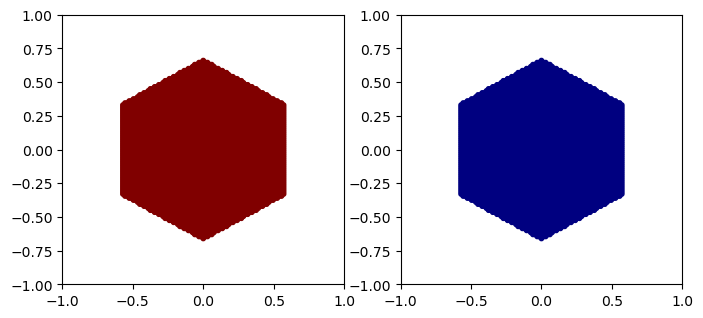

In [ ]:
import numpy as np
import crystal as cr
import grid as grid
from Graphene_TightBinding import TB_graphene_CMCP, qe, epsk, hbar
from Field import polarizedElectricField, lambda2T, env_sin2
import matplotlib.pyplot as plt

def plot_Cv_Cc(tb: TB_graphene_CMCP, s=.1):
    fig,ax=plt.subplots(1,2,figsize=(8,3.5))

    for iax in ax:
        iax.set_xlim(-1,1)
        iax.set_ylim(-1,1)

    x=tb.k
    ax[0].scatter(x[:,0],x[:,1], c=np.abs(tb.Cv()[:])**2, s=s, cmap='jet')
    ax[1].scatter(x[:,0],x[:,1], c=np.abs(tb.Cc()[:])**2, s=s,cmap='jet')

# Create an hexagonal grid

filter=grid.polygonfilter
filter_args={'nsides':6, 'radius': 2/3}
ggr=grid.UniformCartesianGrid(2,[[-0.75,0.75],[-0.75,0.75]],[100,100], origin=(0.0,0), filter=filter, filter_args= filter_args)


#print(ggr.x)
# Create the graphene crystal
gcr=cr.crystal(cr.species['graphene'], grid=ggr, space='reciprocal')

# Create the Field
lambda0=3000e-9
T0=lambda2T(lambda0)
#npt=1024*32
npt=1024*64
tt=grid.UniformCartesianGrid(1,limits=[0,8*T0], nptx=npt)

Efield=polarizedElectricField(tt,I_W__cm2=5e10,lambda0_nm=lambda0*1e9, env=env_sin2, phi_rad=-np.pi/2, chi_rad=np.pi/2,ellip=0)


# Create the TightBinding object

gtb=TB_graphene_CMCP(gcr, Efield)

dipole_x,dipole_y=gtb.rk_dipole(npt=500)

plot_Cv_Cc(gtb, s=10)




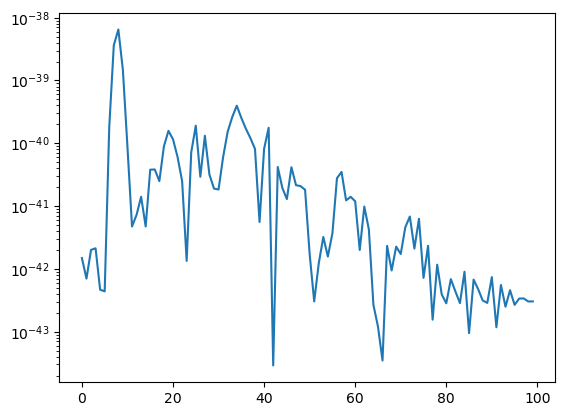

In [4]:
import numpy as np
import matplotlib.pyplot as plt


X = np.fft.fft(np.gradient(np.gradient(np.real(dipole_y))))

X=X[0:100]

plt.figure()
plt.semilogy(np.abs(X)**2)

#plt.semilogy(np.abs(np.fft.fft(dipole_x))**2)
#plt.plot(np.real(dipole_x[0:-1]))




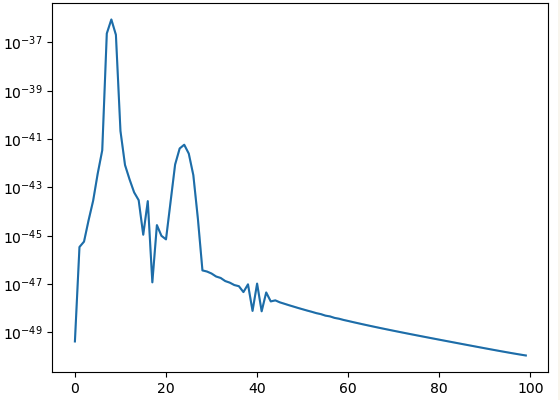

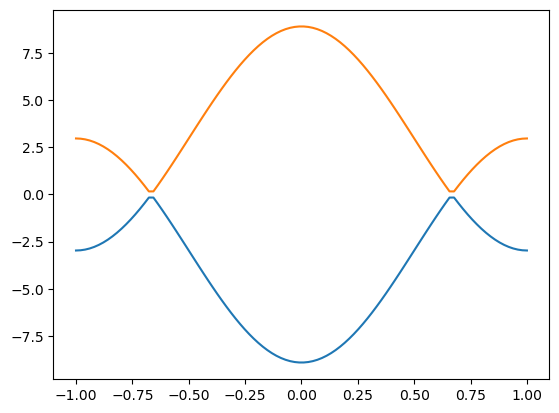

In [27]:
from scipy.constants import eV

ky=np.linspace(-1,1,100)

y=gtb.Ek(0,ky)/eV

plt.plot(ky, y[:,0])
plt.plot(ky, y[:,1])

In [9]:
np.angle(0)

np.float64(0.0)